# Cell Voltage Exploratory Data Analysis 
**Date:** 2026-03-27 | **Runs:** 4 | **Pack:** 84-cell 
## Summary
Pack behavior reveals significant cell imbalance driven by a small number of identifiable weak cells,
with an active P0A80 fault and DCL throttling confirmed at the pack level.
See conclusions for details.

**Imports & Configs**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATHS = sorted([
    '../data/raw/cellvoltages_2026-03-27-18-51-29.csv',
    '../data/raw/cellvoltages_2026-03-27-19-01-44.csv',
    '../data/raw/cellvoltages_2026-03-27-19-03-55.csv',
    '../data/raw/cellvoltages_2026-03-27-19-14-37.csv',
])
N_CELLS = 84

lsu_colors = ["#4E2A84", "#FDD023", "#7F857765", "#000000"]  # purple, gold, gray, black
sns.set_theme(style='darkgrid')
sns.set_palette(sns.color_palette(lsu_colors))
plt.rcParams['figure.figsize'] = (14, 4)

**Dataframe Cleaning**

In [15]:
DROP_COLS = ([f'Cell Resistance {i}' for i in range(1, N_CELLS + 1)] +
             [f'Open Cell Voltage {i}' for i in range(1, N_CELLS + 1)])  # Impedance Analysis TBA

CV_COLS = [f'Cell Voltage {i}' for i in range(1, N_CELLS + 1)]  # Cell Voltage Columns

runs = []
cumulative_offset = 0.0
for i, path in enumerate(PATHS):
    raw = pd.read_csv(path)
    raw.columns = raw.columns.str.strip()
    raw = raw.drop(columns=DROP_COLS)
    raw = raw.dropna(axis=1, how='all')  # Delete BMS trailing comma
    raw['Pack Current'] = raw['Pack Current'] * -1  # Make positive when Charging (human intuitive)
    raw['Time'] = pd.to_datetime(
        raw['Time'].str.replace(r'\s+[A-Z]{2,4}\s+', ' ', regex=True),
        format='%a %b %d %H:%M:%S %Y')
    local_elapsed_m = (raw['Time'] - raw['Time'].iloc[0]).dt.total_seconds() / 60
    raw['elapsed_m'] = local_elapsed_m + cumulative_offset
    cumulative_offset = raw['elapsed_m'].iloc[-1] + (1 / 60)  # ~1s gap between runs
    raw['run_id'] = f'run_{i + 1:03d}'
    runs.append(raw)

df = pd.concat(runs, ignore_index=True)

def annotate_runs(ax):
    """Mark run boundaries on a time-series plot."""
    for run, g in df.groupby('run_id'):
        ax.axvline(g['elapsed_m'].iloc[0], color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

print(df.isnull().sum().sum(), 'total missing values')

0 total missing values


**Pack Data Overview**

In [16]:
print(f'Session duration: {df["elapsed_m"].max():.1f} min  ({df["elapsed_m"].max() * 60:.0f} sec)')
print(f'Total rows: {len(df)}')
for run, g in df.groupby('run_id'):
    print(f'  {run}: {len(g)} rows, {g["elapsed_m"].max() - g["elapsed_m"].min():.1f} min')
print(df.shape)
df.head()

Session duration: 27.0 min  (1619 sec)
Total rows: 2816
  run_001: 522 rows, 9.7 min
  run_002: 53 rows, 0.6 min
  run_003: 1342 rows, 10.5 min
  run_004: 899 rows, 6.1 min
(2816, 101)


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Cell Voltage 77,Cell Voltage 78,Cell Voltage 79,Cell Voltage 80,Cell Voltage 81,Cell Voltage 82,Cell Voltage 83,Cell Voltage 84,elapsed_m,run_id
0,2026-03-27 18:51:35,53.0,306.5,4.9,6,198,19,3.6962,31,3.5873,...,3.6476,3.6469,3.6479,3.6461,3.6472,3.6510,3.6460,3.6452,0.000000,run_001
1,2026-03-27 18:51:36,53.0,306.6,4.7,6,198,19,3.6913,31,3.5865,...,3.6482,3.6481,3.6486,3.6471,3.6476,3.6516,3.6467,3.6464,0.016667,run_001
2,2026-03-27 18:51:39,53.0,306.5,4.6,6,198,19,3.6948,31,3.5875,...,3.6491,3.6485,3.6500,3.6475,3.6474,3.6513,3.6474,3.6466,0.066667,run_001
3,2026-03-27 18:51:39,53.0,306.5,4.6,6,198,19,3.6948,31,3.5875,...,3.6491,3.6485,3.6500,3.6475,3.6474,3.6513,3.6474,3.6466,0.066667,run_001
4,2026-03-27 18:51:40,53.0,306.6,4.6,6,198,19,3.6887,31,3.5867,...,3.6494,3.6487,3.6490,3.6480,3.6477,3.6513,3.6477,3.6470,0.083333,run_001


**Pack Current & Voltage Over Time**

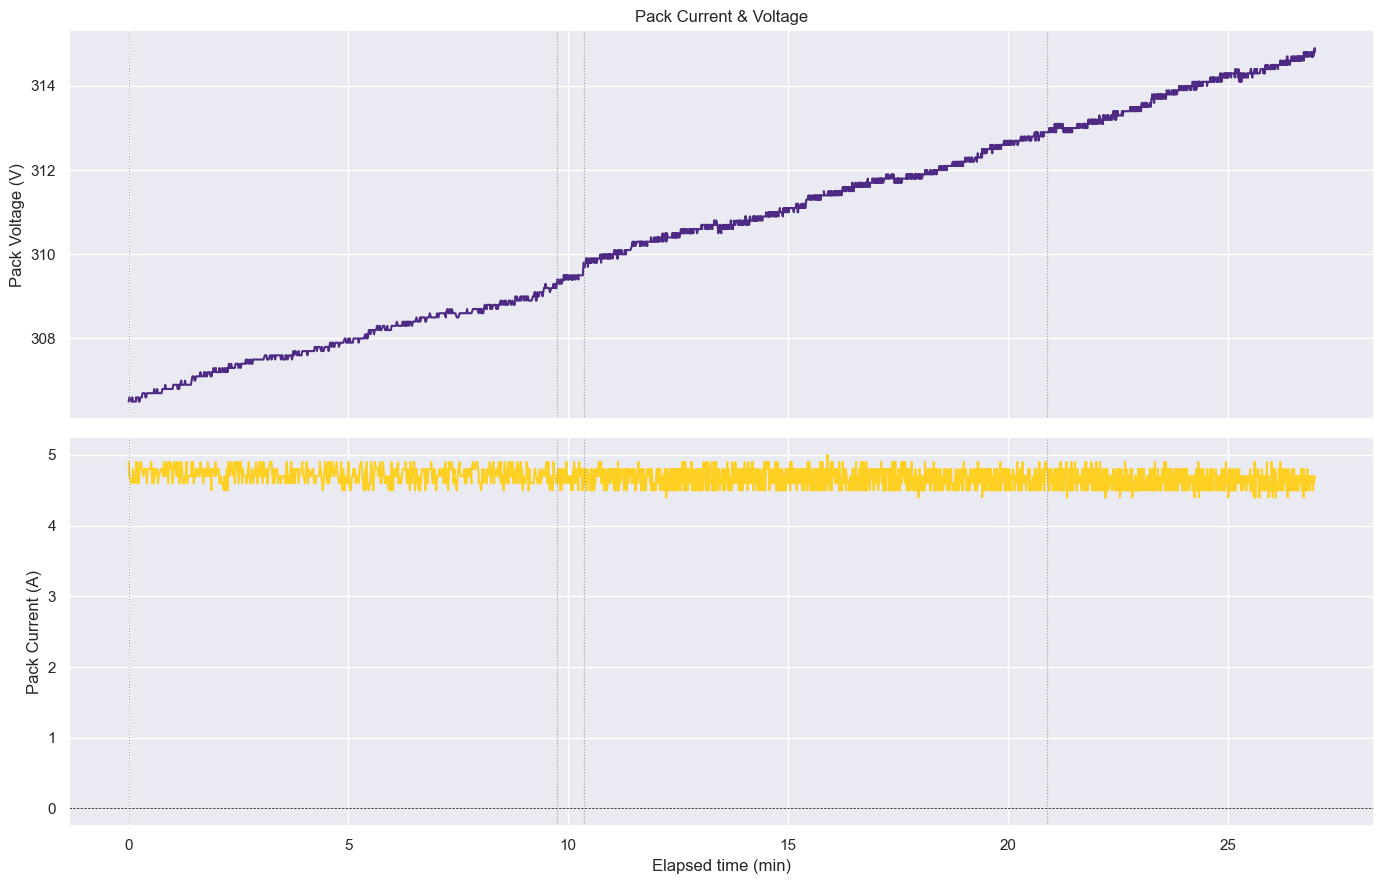

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['elapsed_m'], df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')
annotate_runs(axes[0])

axes[1].plot(df['elapsed_m'], df['Pack Current'], color='#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (A)')
axes[1].set_xlabel('Elapsed time (min)')
annotate_runs(axes[1])

plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

C:\Users\randl\AppData\Local\Temp\ipykernel_23264\4166524199.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']


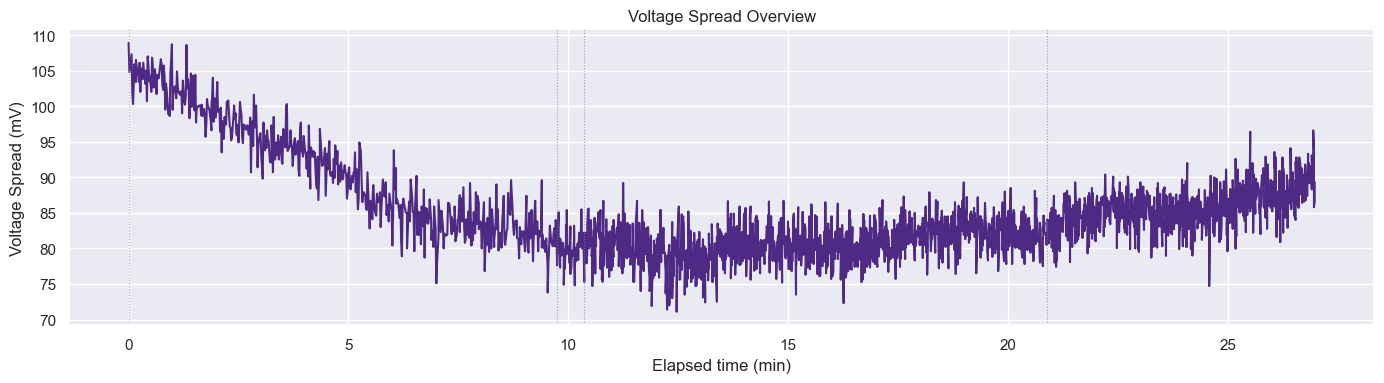

In [18]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (min)')
annotate_runs(ax)

plt.tight_layout()
plt.show()

**Temperature Over Time**

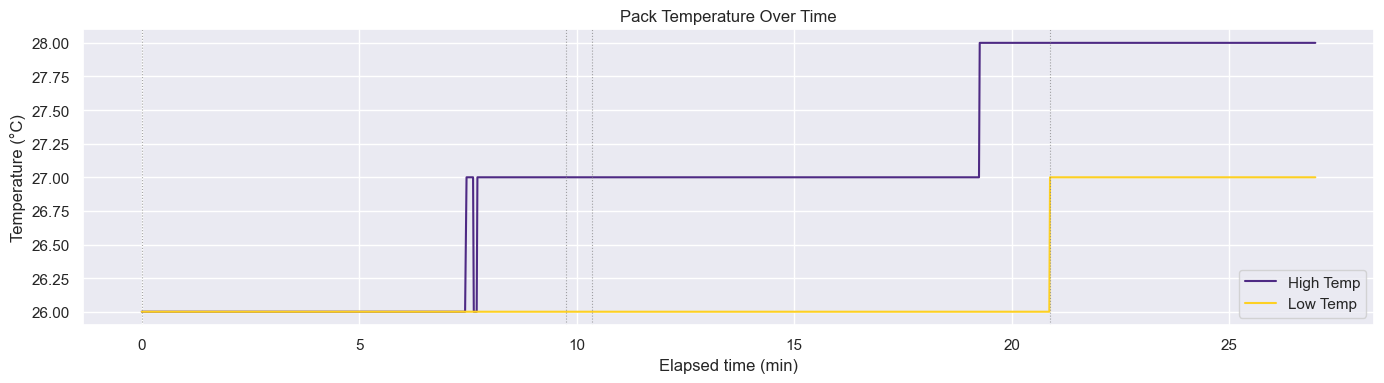

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(df['elapsed_m'], df['High Temperature'], label='High Temp', color='#4E2A84')
ax.plot(df['elapsed_m'], df['Low Temperature'],  label='Low Temp',  color='#FDD023')
ax.set_title('Pack Temperature Over Time')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('Elapsed time (min)')
ax.legend()
annotate_runs(ax)

plt.tight_layout()
plt.show()

C:\Users\randl\AppData\Local\Temp\ipykernel_23264\3474710752.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Temp Spread'] = df['High Temperature'] - df['Low Temperature']


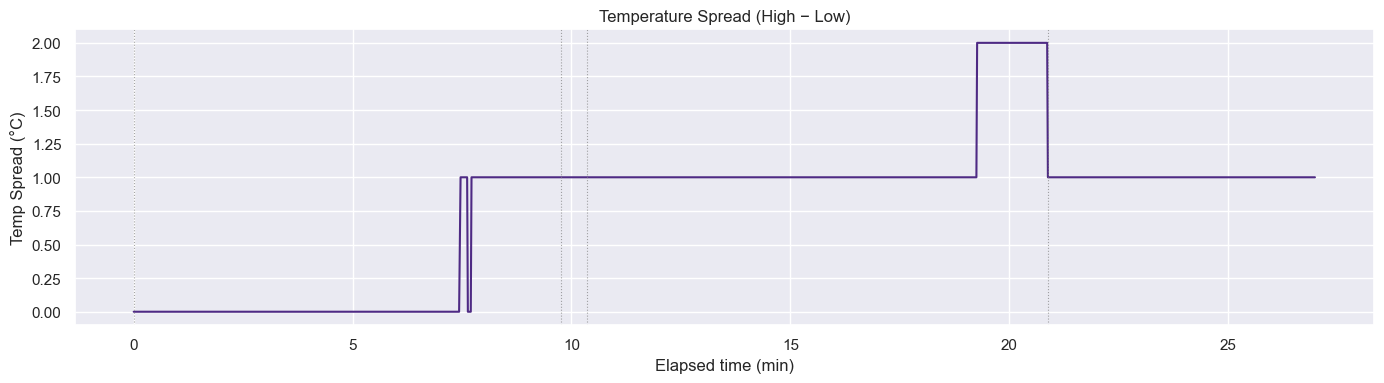

In [20]:
df['Temp Spread'] = df['High Temperature'] - df['Low Temperature']

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Temp Spread'])
ax.set_title('Temperature Spread (High − Low)')
ax.set_ylabel('Temp Spread (°C)')
ax.set_xlabel('Elapsed time (min)')
annotate_runs(ax)

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

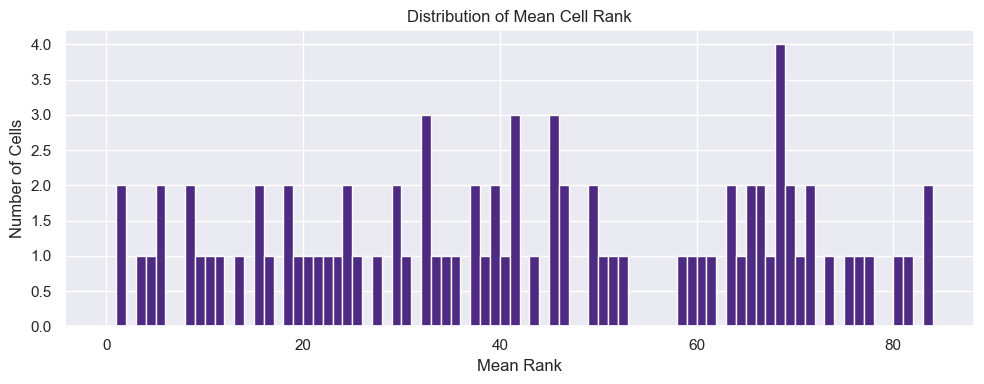

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 1))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')

plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score (Std Deviations From Pack Mean)**

Cell Voltage 31   -4.737018
Cell Voltage 67   -4.443451
Cell Voltage 73   -1.226151
Cell Voltage 9    -1.080899
Cell Voltage 37   -0.923863
dtype: float64
Cell Voltage 19    4.609265
Cell Voltage 2     2.303663
Cell Voltage 71    0.923334
dtype: float64


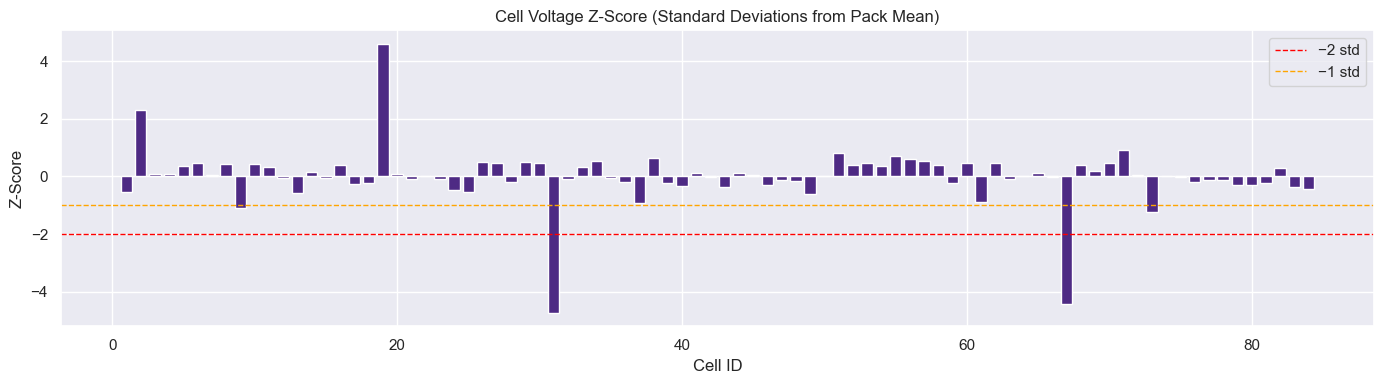

In [23]:
pack_mean_voltage = cell_mean_voltage.mean()
pack_std_voltage = cell_mean_voltage.std()

z_scores = (cell_mean_voltage - pack_mean_voltage) / pack_std_voltage

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, N_CELLS + 1), z_scores)
ax.axhline(-2, color='red', linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()

plt.tight_layout()
print(z_scores.nsmallest(5))
print(z_scores.nlargest(3))
plt.show()

**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 31    3.665684
Cell Voltage 67    3.668329
Cell Voltage 73    3.697321
Cell Voltage 9     3.698630
Cell Voltage 37    3.700045
dtype: float64
Mean Rank of Weakest Cells (1-84)
Cell Voltage 31    1.031250
Cell Voltage 67    1.968750
Cell Voltage 73    3.259766
Cell Voltage 9     4.278054
Cell Voltage 37    5.071733
dtype: float64


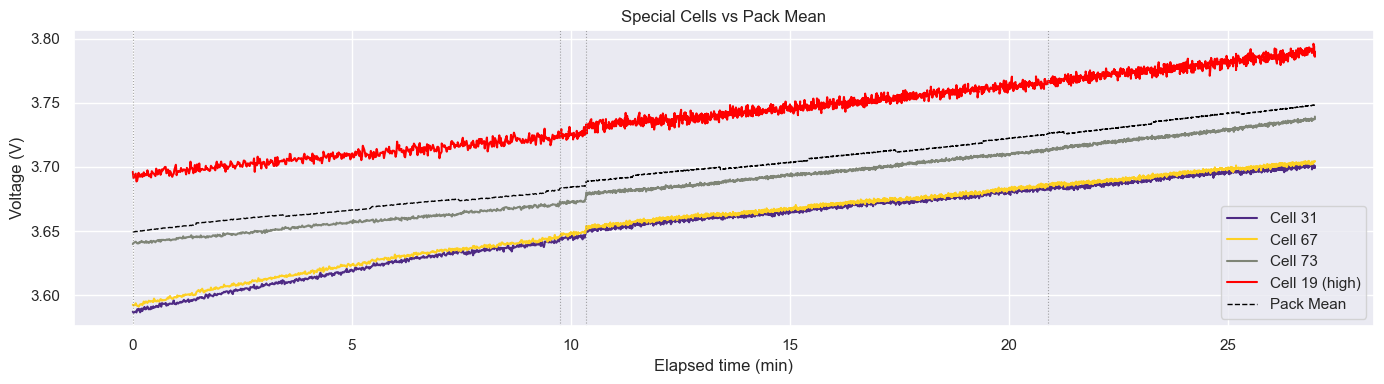

In [24]:
print('Mean Voltage of Weakest Cells (V)')
print(cell_mean_voltage.nsmallest(5))
print('Mean Rank of Weakest Cells (1-84)')
print(cell_mean_rank.nsmallest(5))

# Automatically select 3 lowest and 1 highest z-score cells
weak_cells  = z_scores.nsmallest(3).index.str.extract(r'(\d+)')[0].astype(int).tolist()
strong_cell = z_scores.nlargest(1).index.str.extract(r'(\d+)')[0].astype(int).tolist()
special_cells = weak_cells + strong_cell

pack_mean = df[CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
for cell_id in weak_cells:
    ax.plot(df['elapsed_m'], df[f'Cell Voltage {cell_id}'], label=f'Cell {cell_id}')
for cell_id in strong_cell:
    ax.plot(df['elapsed_m'], df[f'Cell Voltage {cell_id}'], label=f'Cell {cell_id} (high)', color='red')
ax.plot(df['elapsed_m'], pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Voltage (V)')
ax.legend()
annotate_runs(ax)

plt.tight_layout()
plt.show()

## Conclusion
### **Pack Health Overview**
The pack charges with a narrowing voltage spread over time, opening at ~121 mV at 53% SOC and converging to ~26 mV by 66% SOC, indicating the balancer is active and functional. However, the spread at session start is large enough to have triggered a P0A80 Weak Cell fault, and the BMS has reduced the discharge current limit from 198 A to 100 A as a direct consequence. This is not a balancing lag; it reflects genuine capacity loss in specific cells.

### **Cell 31**
Cell 31 registers -6.25 standard deviations from pack mean, the largest single-cell outlier by a wide margin. Its voltage lags the pack throughout the entire session and it is identified as the lowest cell in the resting fault snapshot (3.606 V instantaneous, 3.593 V OCV). Cell 31 is the primary driver of the active P0A80 fault and the DCL reduction. It should be escalated to senior team members for physical inspection and replacement immediately.

### **Cell 67**
Cell 67 registers -4.48 standard deviations from pack mean and follows the same lagging pattern as Cell 31 throughout the session. Its OCV of 3.570 V is 11 mV below pack average at rest. It is a confirmed secondary fault contributor and should be replaced alongside Cell 31.

### **Cell 9**
Cell 9 registers -2.70 standard deviations from pack mean and has an OCV of 3.557 V, which is 24 mV below pack average at rest. While it does not appear as a dominant outlier in the live charge data, the resting OCV value places it among the weakest cells in the pack. It warrants close monitoring in future sessions.

### **Cells 10, 16, 30, 34, 52, 58**
These cells do not stand out significantly in the time-series z-score analysis but each registers at least 20 mV below pack average in the resting OCV data from the fault snapshot. This divergence between live and resting readings is characteristic of cells whose weakness is masked by IR effects during charging. They cannot be meaningfully evaluated from charge logs alone and should be re-examined in future fault snapshots.

### **Notes & Next Steps**
**Note:** The fault snapshot (BMS_FAULT.csv) is a more reliable health document than this time-series log for identifying weak cells, as resting OCV and internal resistance are unaffected by charge current. The two data sources should be read together: the charge log shows how the pack behaves under load, and the fault snapshot shows what the cells actually are at rest.

**Next steps:** Replace cells 31 and 67 before next track use, as the DCL throttling they are causing directly limits vehicle performance. Investigate the cell 2/3/4 module named in the fault subcodes. After replacement, capture a new fault snapshot post-charge-to-rest to confirm P0A80 clears. Re-run this notebook on future session exports to track whether cells 9, 10, 16, 30, 34, 52, and 58 continue to underperform before taking further action.